In [ ]:
### This assignment uses the houses' price dataset provided

In [ ]:
## Linear Regression

## Student Name: Egbuchulam_Nnamdi
## Course: Linear_Regression_Assignment.ipynb
## Date:19/5/2026

In [1]:
# LINEAR REGRESSION WITH NORMALIZATION
# AND yr_renovated COLUMN DROPPED

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


In [2]:
# LOAD DATA

# Load dataset
df = pd.read_csv("data.csv")

# Display first 5 rows
print(df.head())


                  date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  2014-05-02 00:00:00   313000.0       3.0       1.50         1340      7912   
1  2014-05-02 00:00:00  2384000.0       5.0       2.50         3650      9050   
2  2014-05-02 00:00:00   342000.0       3.0       2.00         1930     11947   
3  2014-05-02 00:00:00   420000.0       3.0       2.25         2000      8030   
4  2014-05-02 00:00:00   550000.0       4.0       2.50         1940     10500   

   floors  waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
0     1.5           0     0          3        1340              0      1955   
1     2.0           0     4          5        3370            280      1921   
2     1.0           0     0          4        1930              0      1966   
3     1.0           0     0          4        1000           1000      1963   
4     1.0           0     0          4        1140            800      1976   

   yr_renovated                    str

In [4]:
# DROP yr_renovated COLUMN

df = df.drop(columns=["yr_renovated"])

In [5]:
# DEFINE FEATURES AND TARGET

# Target variable
y = df["price"]

# Features
X = df.drop(columns=["price"])

In [6]:
# IDENTIFY NUMERIC & CATEGORICAL COLUMNS

numeric_columns = X.select_dtypes(include=np.number).columns
categorical_columns = X.select_dtypes(exclude=np.number).columns


In [7]:
# PREPROCESSING (NORMALIZATION)

# Numeric preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())      # NORMALIZATION
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_columns),
        ("cat", categorical_transformer, categorical_columns)
    ]
)


In [8]:
# CREATE LINEAR REGRESSION MODEL

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

In [9]:
# SPLIT DATA

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [10]:
# TRAIN MODEL

model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [11]:
# MAKE PREDICTIONS

y_pred = model.predict(X_test)


In [28]:
# EVALUATE MODEL

# Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Root Mean Squared Error
rmse = np.sqrt(mse)

# R² Score
r2 = r2_score(y_test, y_pred)

# Print metrics
print("===== MODEL PERFORMANCE =====")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R² Score: {r2}")



===== MODEL PERFORMANCE =====
Mean Absolute Error (MAE): 303101.3763511047
Mean Squared Error (MSE): 1150025550269.036
Root Mean Squared Error (RMSE): 1072392.4422845566
R² Score: -0.1276459061185451


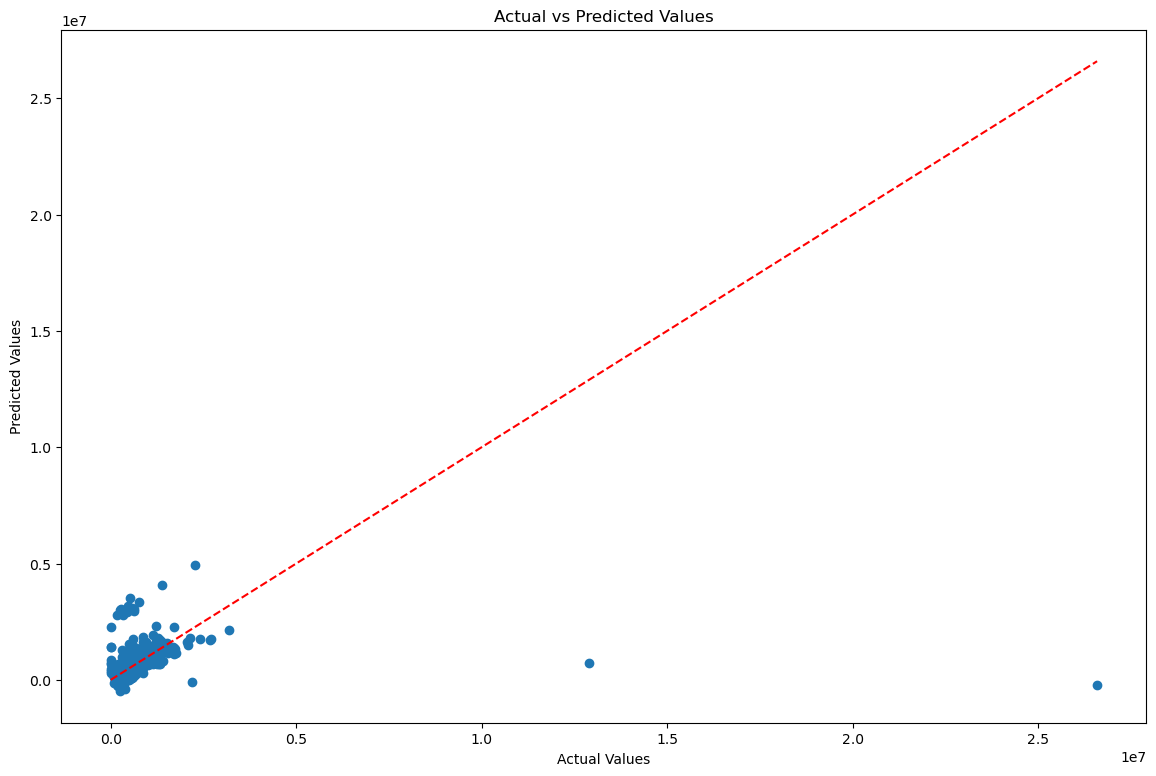

In [25]:
# PLOT ACTUAL VS PREDICTED

plt.figure(figsize=(14, 9))

# Scatter plot
plt.scatter(y_test, y_pred)

# Labels and title
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=1.5
)


# Show plot
plt.show()